In [1]:
from astropy import units as u
from astropy import time
import astropy
import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.frames import Planes
from poliastro.frames.fixed import JupiterFixed
from poliastro.frames.equatorial import JupiterICRS
from astroquery.jplhorizons import Horizons
from copy import deepcopy

from scipy import ndimage
from scipy.spatial.transform import Rotation as scipyRot
from collections import defaultdict
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio
from poliastro.util import norm, time_range
pio.renderers.default = "plotly_mimetype+notebook_connected"
import weakref
from astropy.coordinates import solar_system_ephemeris
from collections.abc import Mapping
from poliastro.extra_util import get_galilean_orbs, ecliptic_slingshot, get_galilean_ephemerides, slingshot_to_another_body
# from poliastro.extra_util import *
solar_system_ephemeris.set("jpl")

from libs import jovian_spenvis_model

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



In [2]:
def dose_rate(r): 
    a=2
    return 1

def tid_for_orbit(orbit,start,end,step=0.1*u.day):
    cum_tid=0
    test_orb=orbit.propagate(start)
    for t in time_range(start,end,step):
        test_orb=orb.propagate(t)
        cum_tid+=dose_rate(np.linalg.norm(test_orb.r))*step
    return cum_tid
    

In [3]:
##Incriments spacecraft by tof_step forward and scans over all allowed tofs

def get_single_burn_elliptical_hohmann_brute_force(target_orb, initial_orb,min_departure_wait=0*u.day,max_depature_wait=50*u.day, min_tof=0.1*u.day, max_tof=50*u.day, tof_step=0.1*u.day, retrograde_only=False,fine_scan=False,max_encounter_v=20*u.km/u.s):
    min_dv=50000*u.m/u.s
    start_epoch=initial_orb.epoch
    final_orb=None
    final_date=None
    final_burn_date=None
    final_targ_orb=None
    final_tof=None
    departure_date_range=np.arange(min_departure_wait.to(u.day).value,max_depature_wait.to(u.day).value,tof_step.to(u.day).value)*u.day
    tof_range=np.arange(min_tof.to(u.day).value,max_tof.to(u.day).value,tof_step.to(u.day).value)*u.day
    for d in departure_date_range:
        pre_burn_orbit=initial_orb.propagate(d)
        for i in range(len(tof_range)):
            arrival_date=start_epoch+d+tof_range[i]
            body_orb=target_orb.propagate(arrival_date+1*u.s)
            #try multiple revolutions of lambert arcs
            for j in range(0,3):
                try:
                    lambert=Maneuver.lambert(pre_burn_orbit,body_orb,M=j)
                    burn=lambert[0]
                    dv=np.linalg.norm(burn[1])
                    #check for max encounter velocity
                    try_orb, dummy = pre_burn_orbit.apply_maneuver(lambert, intermediate=True)
                    encounter_v = norm(try_orb.propagate(arrival_date).v - body_orb.v).to(u.km/u.s)
                    if encounter_v>max_encounter_v:
                        continue
                    #check for retrograde if needed
                    progradeness=np.dot(burn[1].to(u.km/u.s).value,body_orb.v.to(u.km/u.s).value)
                    if retrograde_only and (progradeness)<0:
                        continue
                
                    if dv<min_dv:
                        min_dv=dv
                        final_orb,dummy=pre_burn_orbit.apply_maneuver(lambert,intermediate=True)
                        final_date=arrival_date
                        final_burn_date=d
                        final_targ_orb=body_orb
                        final_tof=tof_range[i]
                        # plotter.plot(final_orb)
                except Exception as e:
                    # print(e)
                    continue
    results=[min_dv,final_orb,final_targ_orb,final_date,final_burn_date]
    print("Best dv:", min_dv)
    if not fine_scan:
        print(f"Refining search around burn at {final_burn_date:.1f} with {final_tof:.1f} transfer time.")
        test_min_tof=final_tof-5*tof_step
        test_max_tof=final_tof+5*tof_step
        test_max_depature_wait=final_burn_date
        transfer=get_single_burn_elliptical_hohmann_brute_force(
            target_orb,
            initial_orb,
            min_departure_wait=test_max_depature_wait-5*tof_step,
            max_depature_wait=test_max_depature_wait+tof_step*5,
            min_tof=test_min_tof,
            max_tof=test_max_tof,
            tof_step=tof_step/10,
            retrograde_only=retrograde_only,
            fine_scan=True,
            max_encounter_v=max_encounter_v          
        )
        results=transfer
    return results

In [4]:

start_date= time.Time("2037-06-11 00:01", scale="utc").tdb
end_date= time.Time("2037-09-21 00:01", scale="utc").tdb
epochs=time_range(start=start_date,end=end_date,periods=50)

callisto_ephem = Ephem.from_horizons(504,epochs= epochs, attractor= Jupiter,plane=Planes.EARTH_ECLIPTIC)#Callisto is 504
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)
ephemerides = get_galilean_ephemerides(start_date, end_date)


# # Access like this:
europa_ephem = ephemerides[Europa]
io_ephem = ephemerides[Io]
ganymede_ephem = ephemerides[Ganymede]
callisto_ephem = ephemerides[Callisto]
galilean_orbs = get_galilean_orbs(start_date,start_date+10*u.day)

# Access like this:
europa_orb = galilean_orbs[Europa]
print(europa_orb)
europa_orb= Orbit.from_ephem(attractor=Jupiter,ephem=europa_ephem,epoch=start_date)
ganymede_orb= Orbit.from_ephem(attractor=Jupiter,ephem=ganymede_ephem,epoch=start_date)
io_orb= Orbit.from_ephem(attractor=Jupiter,ephem=io_ephem,epoch=start_date) 
callisto_orb= Orbit.from_ephem(attractor=Jupiter,ephem=callisto_ephem,epoch=start_date)

r_perijove = 1.05*Jupiter.R 
r_apijove = 165*Jupiter.R
a_start = (r_perijove+r_apijove)/2
ecc_start = (r_perijove-r_apijove)/(r_perijove+r_apijove)

starship_orb=Orbit.from_classical(
Jupiter, a_start, ecc_start, io_orb.inc, 
io_orb.raan, 0*u.deg, -2*u.deg,
start_date,plane=Planes.EARTH_ECLIPTIC)


print(starship_orb.period.to(u.day))

#List will store all orbits
all_orbits=[]



665064 x 676992 km x 2.0 deg orbit around Jupiter (♃) at epoch 2037-06-11 00:02:09.185 (TDB)
93.4233513755375 d


In [5]:
post_joi_orb_for_rad=Orbit.from_classical(
Jupiter, a_start, ecc_start, io_orb.inc, 
io_orb.raan, 0*u.deg, -179*u.deg,
start_date-20*u.day,plane=Planes.EARTH_ECLIPTIC)

all_orbits.insert(0,post_joi_orb_for_rad)

In [6]:
print((r_apijove/Jupiter.R.to(u.km)).to(u.one))
print((r_perijove/Jupiter.R.to(u.km)).to(u.one))

165.0
1.05


In [7]:
#Raise perijove to encounter next moon
transfer_to_next_moon=get_single_burn_elliptical_hohmann_brute_force(
    ganymede_orb,
    starship_orb,
    max_depature_wait=15*u.day,
    tof_step=0.1*u.day,
    min_tof=30*u.day,
    max_tof=105*u.day,
    retrograde_only=False,
    max_encounter_v=6*u.km/u.s
)

Best dv: 891.226128253608 m / s
Refining search around burn at 9.1 d with 57.2 d transfer time.
Best dv: 891.1891010286732 m / s


In [8]:
def rotate_plot_90(ax, ccw=True):
    # 90° rotation: CCW (x,y)->(-y,x), CW (x,y)->(y,-x)
    for line in ax.lines:
        x, y = line.get_data()
        x = np.asarray(x); y = np.asarray(y)
        if ccw:
            line.set_data(-y, x)
        else:
            line.set_data(y, -x)

    # scatter/path collections (often used for points)
    for col in ax.collections:
        if hasattr(col, "get_offsets"):
            off = np.asarray(col.get_offsets())
            if off.size and off.shape[1] >= 2:
                x = off[:, 0]; y = off[:, 1]
                new_off = np.column_stack((-y, x)) if ccw else np.column_stack((y, -x))
                col.set_offsets(new_off)

    # patches (often circles for bodies)
    for p in ax.patches:
        if hasattr(p, "center"):
            x, y = p.center
            p.center = (-y, x) if ccw else (y, -x)

    ax.set_aspect("equal", adjustable="box")
    ax.relim()
    ax.autoscale_view()


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"



Arrival on moon at 2037-08-16 07:14:09.185


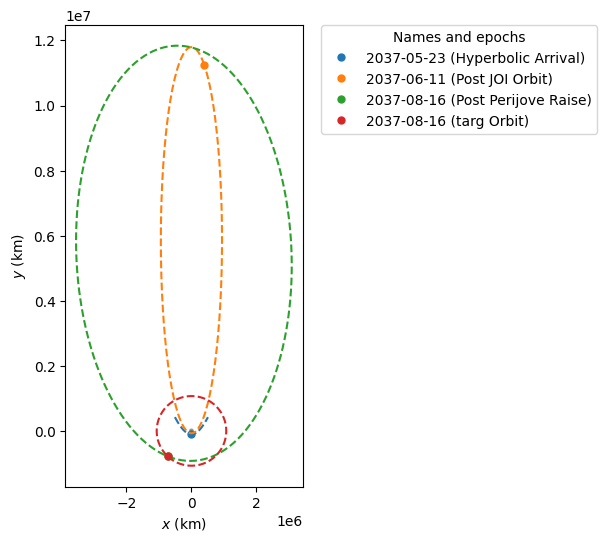

Initial orbit has ecc of 1.047393237114361
Capture into 11796180 x 75067 km x 2.2 deg orbit around Jupiter (♃) at epoch 2037-06-11 00:02:09.185 (TDB)
Initial orbital period is 93.4233513755375 d
Burn to reach Io with 924642 x 11848969 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-06-20 01:42:57.185 (TDB)
Arrival at Ganymede (●) with 6.00 km / s v infty


In [9]:
#C3 only orbit calc
c3_a=56*(u.km**2)/(u.s**2)
r_p = Jupiter.R*0.5#arrival periapsis
a_exit = -(Jupiter.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+Jupiter.R) / a_exit

arrival_orbit = Orbit.from_classical(
    Jupiter,
    a_exit,
    ecc_exit,
    0 * u.deg,
    starship_orb.raan,
    starship_orb.argp+180*u.degree,
    0 * u.deg,  # We don't mind
    time.Time("2037-05-23 00:01", scale="utc"),
    plane=Planes.EARTH_ECLIPTIC
)
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
io_arrival_date_1=transfer_to_next_moon[3]
# plotter.plot(callisto_orb, label="Callisto Orbit")
plotter.plot(arrival_orbit,label='Hyperbolic Arrival')

plotter.plot(starship_orb.propagate(0*u.day), label="Post JOI Orbit")
plotter.plot(transfer_to_next_moon[1].propagate(io_arrival_date_1), label="Post Perijove Raise")

plotter.plot(ganymede_orb.propagate(io_arrival_date_1), label="targ Orbit")
print(f"Arrival on moon at {transfer_to_next_moon[3]}")
pre_io_starship_flyby=transfer_to_next_moon[1].propagate(io_arrival_date_1)

# Get the matplotlib Axes (poliastro versions differ: ax vs _ax)
ax = getattr(plotter, "ax", None) or plotter._ax

# Example: zoom to a +/- 5e8 km box around (0,0)
# range=5e9
# ax.set_xlim(-range, range)
# ax.set_ylim(-range, range)
ax.set_aspect("equal", adjustable="box")
rotate_plot_90(ax, ccw=False)   # 90° counter-clockwise
plt.show()
print(f"Initial orbit has ecc of {arrival_orbit.ecc}")
print(f"Capture into {starship_orb}")
print(f"Initial orbital period is {starship_orb.period.to(u.day)}")
print(f"Burn to reach Io with {transfer_to_next_moon[1]}")

all_orbits.append(starship_orb)
all_orbits.append(transfer_to_next_moon[1])

arrival_sped=np.linalg.norm(transfer_to_next_moon[1].propagate(io_arrival_date_1).v-ganymede_orb.propagate(io_arrival_date_1).v)
print(f"Arrival at {Ganymede} with {arrival_sped:.2f} v infty")

arrival_at_next_moon_orb=transfer_to_next_moon[1].propagate(io_arrival_date_1)

In [10]:
def assist_possible_periods(spacecraft_orb, body_orb, body, r_p_min=10*u.km, r_p_max=5000*u.km, num_samples=500):#finds possible periods of orbit around attractor given flyby
    periods=np.zeros((num_samples,2))
    periaps=np.zeros((num_samples))
    attractor=spacecraft_orb.attractor
    flyby_dist=np.linalg.norm(spacecraft_orb.r-body_orb.r)
    if(flyby_dist)<4*body.R:
        rel_vel=spacecraft_orb.rv()[1]-body_orb.rv()[1]
        rel_speed=np.linalg.norm(rel_vel)
        r_ps = body.R + np.linspace(r_p_min.to(u.km).value, r_p_max.to(u.km).value, num=num_samples) * u.km
        rot_angs = 2 * np.arcsin(1 / ((r_ps * rel_speed**2 / body.k) + 1 * u.one))
        # Rotation axis in ecliptic plane
        axis = np.array([0, 0, 1.0])
        axis = axis / np.linalg.norm(axis)
        # Try both rotation directions (leading/trailing side flybys)
        for j,sign in enumerate([1,-1]):
            for i, rot_ang in enumerate(rot_angs):
                # Rotate the relative velocity
                rot = scipyRot.from_rotvec(sign * axis * rot_ang.value)
                rel_vel_out = rot.apply(rel_vel.value) * u.km / u.s
                
                # Calculate post-assist velocity in attractor frame
                post_assist_vel = rel_vel_out + body_orb.rv()[1]
                
                # Create orbit from post-assist state
                test_orb = Orbit.from_vectors(
                    attractor, 
                    body_orb.r, 
                    post_assist_vel, 
                    spacecraft_orb.epoch,
                    plane=Planes.EARTH_ECLIPTIC
                )
                periods[i][j]=test_orb.period.to(u.day).value
                periaps[i]=r_ps[i].to(u.km).value
        return (periods,periaps)
                
                
    else:
        print(f"Trajectory does not fly past {body} closely enough - misses by {flyby_dist.to(u.km):.1f}")
        return None

def resonance_search(spacecraft_orb,body,r_p_min=10*u.km, r_p_max=5000*u.km, lower=True, numerator_prioritize=True, max_numerator=9,sim_start_date=time.Time("2037-06-11 00:01", scale="utc").tdb):
    used_orbit=deepcopy(spacecraft_orb)
    attractor=spacecraft_orb.attractor
    galilean_orbs=get_galilean_orbs(sim_start_date,sim_start_date+10*u.day)
    prelim_body_orb= galilean_orbs[body].propagate(used_orbit.epoch)
    postflyby_data=assist_possible_periods(used_orbit, prelim_body_orb, body,r_p_min=r_p_min, r_p_max=r_p_max,num_samples=10000)
    possible_resonances=[]
    if postflyby_data is not None:
        ##Check which side gives lower periods
        trailing_mean_period = np.mean(postflyby_data[:][0])
        leading_mean_period = np.mean(postflyby_data[0][:, 1])
        if trailing_mean_period < leading_mean_period:
            lower_side = 0  # Trailing side (sign=1)
            # print("Trailing side flybys give lower periods")
        else:
            lower_side = 1  # Leading side (sign=-1)
            # print("Leading side flybys give lower periods")

        side=lower_side if lower else 1-lower_side

        sign=int((-1)**(side))

        
        #generate allowed resonances      
        pairs = np.array([(i, j)
                  for i in range(1, max_numerator + 1)
                  for j in range(1, max_numerator + 1)
                  if math.gcd(i, j) == 1], dtype=int)
        # optional: the fraction values
        vals = pairs[:, 0] / pairs[:, 1]
        # print(vals)
        possible_resonant_periods = vals*prelim_body_orb.period.to(u.day)
        for i,period in enumerate(postflyby_data[0][:,side]):
            for j,test_period in enumerate(possible_resonant_periods):
                t_ratio=(((period*u.day)/test_period).to(u.one)).value
                if abs(1-t_ratio)<0.001:
                    # print(f"At {test_period:.1f} ie {pairs[j]} with flyby at {postflyby_data[1][i]*u.km-body.R.to(u.km)}")
                    possible_resonances.append((pairs[j], postflyby_data[1][i]*u.km-body.R.to(u.km)))
        # print(possible_resonances)
        
        groups = defaultdict(list)

        for frac_arr, rp in possible_resonances:
            key = tuple(frac_arr.tolist())      # e.g. (5, 7)
            groups[key].append(rp.to(u.km))     # keep as Quantity
        # one averaged periapsis per resonance fraction
        averaged = []
        for key, rps in groups.items():
            rp_mean = np.mean(u.Quantity(rps))  # Quantity mean, stays in km
            averaged.append((np.array(key, dtype=int), rp_mean, len(rps)))         
        if numerator_prioritize:#pick the resonance with the lowest numerator
            averaged.sort(key=lambda x: (x[0][0], x[1].value))  # Sort by numerator, then by periapsis
        h_p=averaged[0][1]
        chosen_resonance=averaged[0][0]
        
        tof=prelim_body_orb.period * (chosen_resonance[0])
        # print(f"Time of flight is {tof.to(u.day):.1f}, which is {chosen_resonance[0]} times the period of the moon.")
        arrival_date=used_orbit.epoch + tof
        target_orb=prelim_body_orb.propagate(arrival_date)
        print(f"Going for {chosen_resonance} resonance with periapsis at {h_p}, time till next encounter is {tof.to(u.day):.2f}")
        print(f"Flyby v inf speed is {np.linalg.norm(used_orbit.v-prelim_body_orb.v):.2f}")
        simple_ecliptic_vector,dummy2=ecliptic_slingshot(used_orbit,prelim_body_orb,body,h_p,1*sign)
        
        #find actual transfer
        print(f"Spacecraft does {chosen_resonance[1]-1} complete orbits before arriving, {body} does {chosen_resonance[0]-1}.")
        # print(f"Period of spacecraft orbit should be {(tof/chosen_resonance[1]).to(u.day):.1f}, actually is {dummy2.period.to(u.day):.1f}")
        # plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)       
        # plotter.plot(spacecraft_orb,label='initial_orb')
        # plotter.plot(target_orb,label='destination')
        orb_tuple=((dummy2.r_p/attractor.R).to(u.one), (dummy2.r_a/attractor.R).to(u.one))       
        
        
        print(f"Arrives with distance of {np.linalg.norm(dummy2.propagate(target_orb.epoch).r-target_orb.r):.2f}")
        if dummy2.r_p.to(u.km)<1.05*attractor.R.to(u.km):
            print(f"Orbit crashes into {attractor}")
        return dummy2,tof,orb_tuple
    else:
        print("Ending resonance search.")
        return None



def multiple_resonances(spacecraft_orb, body, num_flybys, lower=False, max_num=9):
    active_orb=deepcopy(spacecraft_orb)
    orbits_so_far=[]
    for f in range(num_flybys):
        print(f"Flyby {f+1}")
        orbits_so_far.append(active_orb)
        try:
            dorb,time,orb_tuple=resonance_search(active_orb,body,lower=lower,max_numerator=max_num)
            active_orb=dorb.propagate(time)
            print(f"Orbit params post flyby are {orb_tuple}")
            continue
        except Exception as e:
            print(f"Failed to find resonance: {e}")
    orbits_so_far.append(active_orb)
    
    return orbits_so_far

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"



In [11]:
orbits_post_ganymede=multiple_resonances(arrival_at_next_moon_orb,Ganymede,5,lower=True)

Flyby 1
Going for [5 1] resonance with periapsis at 268.7573757375739 km, time till next encounter is 35.78 d
Flyby v inf speed is 6.00 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 4.
Arrives with distance of 1090.39 km
Orbit params post flyby are (<Quantity 12.06267973>, <Quantity 75.51087426>)
Flyby 2
Going for [3 1] resonance with periapsis at 1331.484148414842 km, time till next encounter is 21.47 d
Flyby v inf speed is 5.99 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 2.
Arrives with distance of 72.66 km
Orbit params post flyby are (<Quantity 11.25031039>, <Quantity 51.04647952>)
Flyby 3
Going for [2 1] resonance with periapsis at 1113.898389838984 km, time till next encounter is 14.31 d
Flyby v inf speed is 5.99 km / s
Spacecraft does 0 complete orbits before arriving, Ganymede (●) does 1.
Arrives with distance of 226.17 km
Orbit params post flyby are (<Quantity 10.21283236>, <Quantity 37.32815326>)
Flyby 4
Going for [

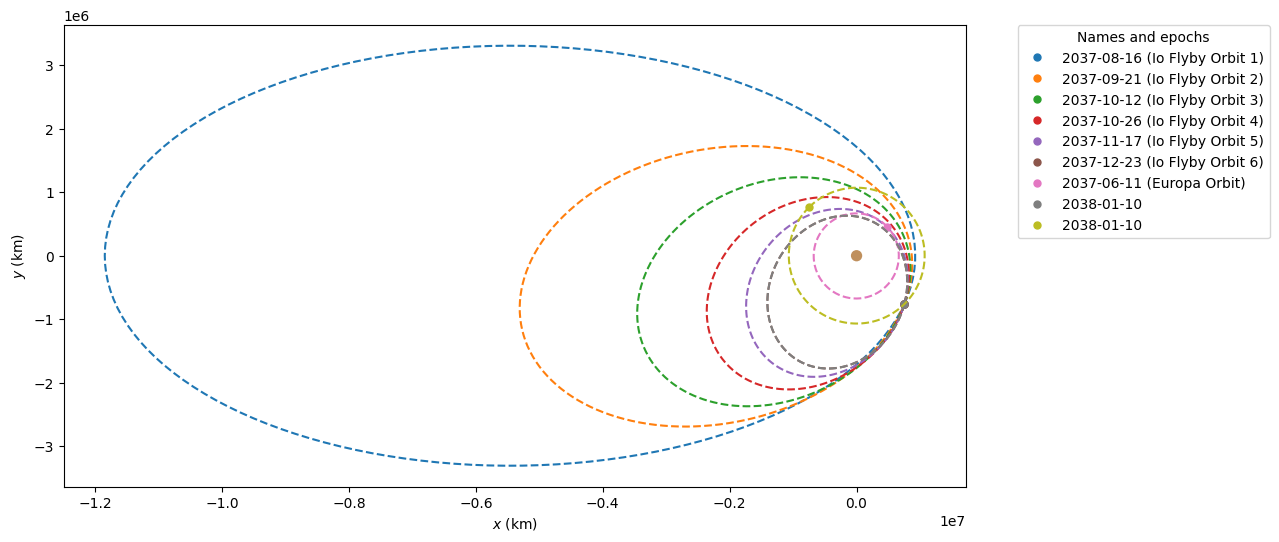

In [12]:
plotter=StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
for i,orb in enumerate(orbits_post_ganymede):
    all_orbits.append(orb)
    plotter.plot(orb, label=f"Io Flyby Orbit {i+1}")
plotter.plot(europa_orb, label="Europa Orbit")

next_ganymede_arrival=orbits_post_ganymede[-1].propagate(orbits_post_ganymede[-1].period*2)
plotter.plot(next_ganymede_arrival)
ganymede_orb_at_assist_4=ganymede_orb.propagate(next_ganymede_arrival.epoch)
plotter.plot(ganymede_orb_at_assist_4)

In [115]:

def slingshot_to_another_body_temp(spacecraft_orb, flyby_body,target_body,date_range, max_tof=50*u.day,tof_step=0.1*u.day):
    galilean_orbs = get_galilean_orbs(date_range[0],date_range[-1])
    # print(galilean_orbs)
    target_body_orb_initial=galilean_orbs[target_body]
    flyby_body_orb=galilean_orbs[flyby_body].propagate(spacecraft_orb.epoch)
    initial_dist=np.linalg.norm(spacecraft_orb.r-flyby_body_orb.r)
    initial_sped=np.linalg.norm(spacecraft_orb.v-flyby_body_orb.v)
    lowest_dv=100000*u.m/u.s
    best_orb=None
    target_arrival_orb=None
    print(flyby_body_orb)
    print(target_body_orb_initial)
    arrival_v=spacecraft_orb.v
    if initial_dist>5*flyby_body.R:
        raise ValueError(f"Misses {flyby_body} by {initial_dist:.2f} km.")
    print(max_tof)
    print(tof_step)
    nums=int(max_tof.to(u.day).value/tof_step.to(u.day).value)
    print(type(nums))
    for i in range(nums):
        arrival_date=spacecraft_orb.epoch+i*tof_step
        target_body_orb=target_body_orb_initial.propagate(arrival_date+1*u.s)
        try:
            lambert=Maneuver.lambert(spacecraft_orb,target_body_orb)
            burn=lambert[0]
            dv=np.linalg.norm(burn[1])
            new_spacecraft_orb,dummy=spacecraft_orb.apply_maneuver(lambert,intermediate=True)
            speed_def=np.linalg.norm(new_spacecraft_orb.v.to(u.km/u.s)-arrival_v.to(u.km/u.s))
            angle_dif=np.arccos(np.dot(new_spacecraft_orb.v.to(u.km/u.s).value,arrival_v.to(u.km/u.s).value)/(norm(new_spacecraft_orb.v).to(u.km/u.s).value*norm(arrival_v).to(u.km/u.s).value))*u.rad
            r_p=((math.sin(angle_dif.value/2)**(-1))-1)/(initial_sped**2)*flyby_body.k
            if speed_def<200*u.m/u.s:
                lowest_dv=dv
                best_orb=new_spacecraft_orb
                target_arrival_orb=target_body_orb
                print(f"Found transfer with {angle_dif}, peripasis of {(r_p-flyby_body.R).to(u.km):.2f}.")
        except Exception as e:
            continue
    print(f"Min dv {lowest_dv:.1f}")
    return best_orb, target_arrival_orb

In [119]:
pre_burn_orb=orbits_post_ganymede[-1]
europa_near_arrival=europa_orb.propagate(pre_burn_orb.epoch)
transfer_to_europa=get_single_burn_elliptical_hohmann_brute_force(
    europa_near_arrival,
    pre_burn_orb,
    max_depature_wait=5*u.day,
    tof_step=0.1*u.day,
    min_tof=3*u.day,
    max_tof=25*u.day,
    retrograde_only=True,
    max_encounter_v=4*u.km/u.s
)

Best dv: 243.04193440772195 m / s
Refining search around burn at 4.9 d with 9.9 d transfer time.
Best dv: 238.13803234107564 m / s


In [ ]:
# ganymede_europa_assist=slingshot_to_another_body_temp(next_ganymede_arrival,Ganymede, Europa,date_range=epochs,tof_step=0.01*u.day)

1067506 x 1073625 km x 2.3 deg orbit around Jupiter (♃) at epoch 2037-11-24 11:40:17.041 (TDB)
665064 x 676992 km x 2.0 deg orbit around Jupiter (♃) at epoch 2037-06-11 00:02:09.185 (TDB)
50.0 d
0.01 d
<class 'int'>
Min dv 100000.0 m / s


In [ ]:
plotter = StaticOrbitPlotter(plane=Planes.EARTH_ECLIPTIC)
plotter.plot()

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"



Arrival speed (at periapsis) is 4.469516817406299 km / s
EOI burn with 3.06 km / s delta-V.
Final orbit velocity is 1.4100674772998854 km / s


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"



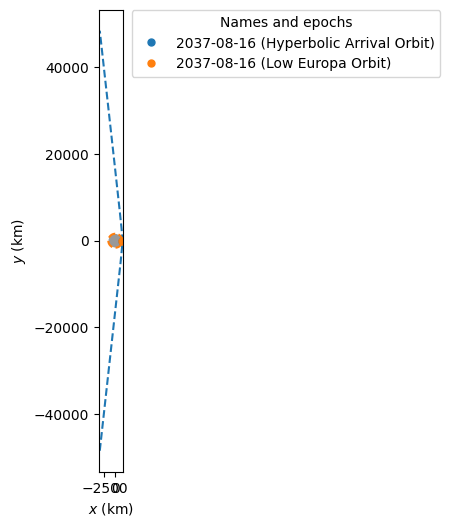

In [120]:
v_sc_arriv = 4*u.km/u.s
body1=Europa
c3_a = np.linalg.norm(v_sc_arriv)**2
final_arrival_date=io_arrival_date_1

#C3 only orbit calc
r_p = 50*u.km#arrival periapsis
a_exit = -(body1.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+body1.R) / a_exit
end_date = final_arrival_date

arrival_orbit = Orbit.from_classical(
    body1,
    a_exit,
    ecc_exit,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,  # We don't mind
    time.Time(end_date, scale="utc"),
)
arrival_circular_orbit = Orbit.circular(body1,alt = r_p, epoch=time.Time(end_date, scale="utc"))
EOI_DV = np.linalg.norm(arrival_orbit.v)-np.linalg.norm(arrival_circular_orbit.v)

print(f"Arrival speed (at periapsis) is {np.linalg.norm(arrival_orbit.v)}")
print(f"EOI burn with {EOI_DV:.2f} delta-V.")
print(f"Final orbit velocity is {np.linalg.norm(arrival_circular_orbit.v)}")


plotter = StaticOrbitPlotter()

plotter.plot(arrival_orbit, label="Hyperbolic Arrival Orbit")
plotter.plot(arrival_circular_orbit, label="Low Europa Orbit")